# 06 — Conditional GANs (cGANs)

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a **conditional GAN**: a GAN whose generator is told *which class* to produce
- Understand how conditioning works: concatenate a label encoding to both G's and D's inputs
- Generate digits **by class**: ask the trained generator for a 0, a 1, ... a 9

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lesson 05 "Building and Training a Simple GAN" — the same two networks, each given the class label as an extra input; the one-hot label encoding is the one from Course 01 (AIAT 111) — Unit 2, lesson 07.

**Used later in:** Course 10 — Unit 3, lesson 03, which applies the identical conditioning trick to a VAE.

---

## Introduction

The GAN from example 05 generates *some* digit — you cannot choose which. A **conditional GAN** (Mirza & Osindero, 2014) fixes that with one idea:

- **Generator**: input becomes `[z ⊕ one-hot(label)]` — G learns p(x | label)
- **Discriminator**: input becomes `[image ⊕ one-hot(label)]` — D judges "is this a real *seven*?", not just "is this real?"

D checking image–label *pairs* is what forces G to actually honor the label: producing a good digit of the wrong class gets punished.

---

## 🌍 Why this lesson exists — ControlNet, and the end of re-rolling the prompt

The one-line change in this notebook — put the condition into *both* networks — is the same change that made image generation usable as a tool rather than a slot machine. **ControlNet** (Zhang, Rao & Agrawala, ICCV 2023, arXiv 2302.05543) conditions Stable Diffusion on a pose skeleton, depth map or edge map, and is now the standard mechanism in the open Stable Diffusion ecosystem for "keep this exact pose / this exact layout". Before conditioning existed, an illustrator wanting a character in a specific pose re-rolled the prompt dozens of times and hoped; after it, the pose is an *input*.

**What goes wrong without this:** an unconditional generator cannot be asked for anything. If your requirement is "a 7", "a shirt in this fabric", "this building at night", you are reduced to sampling until you get lucky — and you have no way to guarantee that every class you need is even reachable.


## How the Code Differs From Example 05

Only three changes — find them in the code below:

1. `G` takes `LATENT_DIM + 10` inputs (noise ⊕ one-hot label)
2. `D` takes `784 + 10` inputs (image ⊕ one-hot label)
3. Every training step draws labels and feeds the *same* label to G and D

Everything else — the adversarial loop, losses, `.detach()` — is identical to example 05.

**Read this as a controlled experiment, because that is what it is.** The baseline is example 05: the same MNIST subset, the same adversarial loop, the same losses, the same `.detach()`. Exactly one thing changes here — the class label enters both G and D. Example 05's generator produced *some* digit and you could not say which; run this one and read the 10-row figure below. If the only change was the label and the only new behaviour is class control, then the label input is what produced it. That is the whole conclusion the figure supports — and note what it does **not** support: the samples are no sharper than example 05's.


Epoch 3/15 — D loss: 0.298  G loss: 3.818


Epoch 6/15 — D loss: 0.208  G loss: 4.587


Epoch 9/15 — D loss: 0.313  G loss: 2.846


Epoch 12/15 — D loss: 0.626  G loss: 1.934


Epoch 15/15 — D loss: 0.859  G loss: 1.534


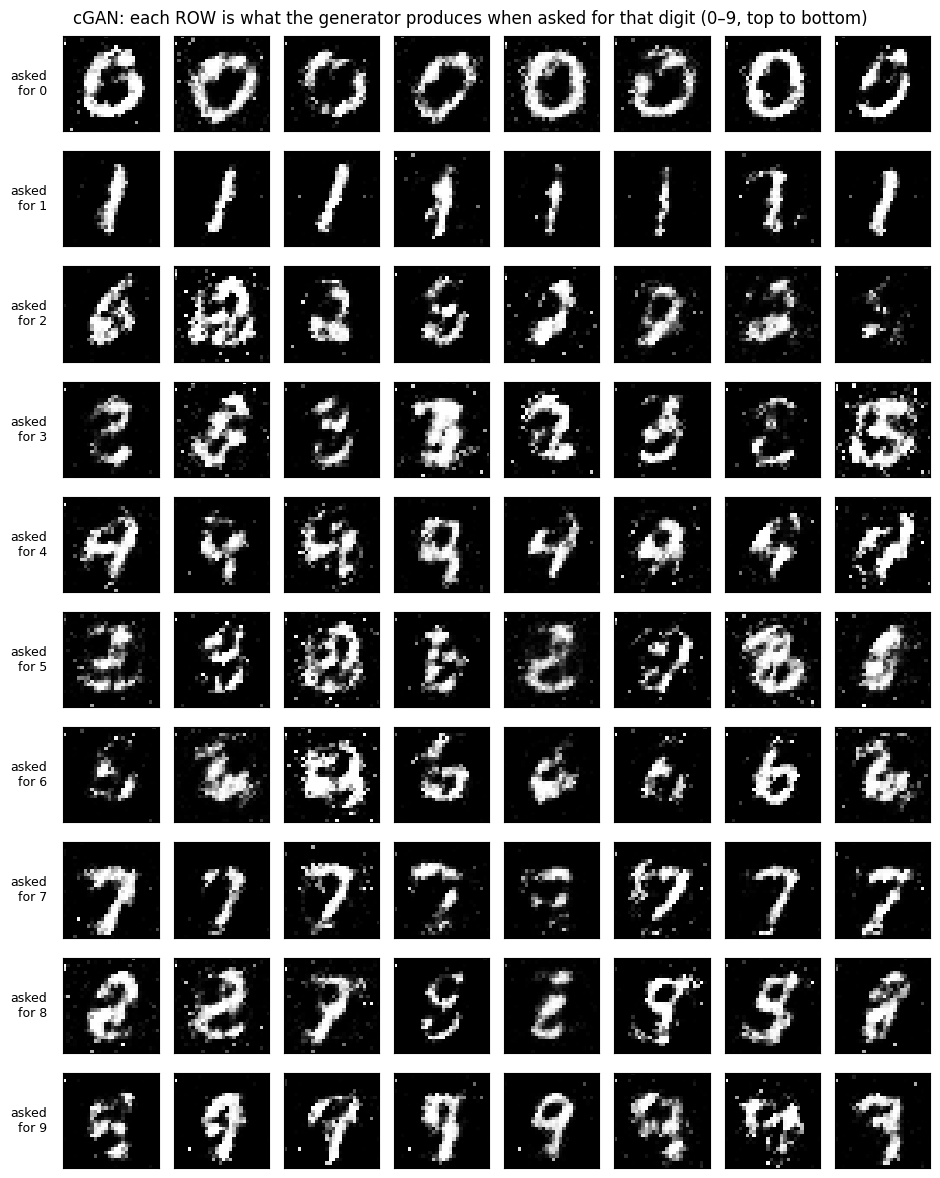

Row-by-row consistency is the CLAIM. Two cells below, an independent
classifier measures how much of it is real, class by class.
(Samples are still rough after 15 CPU epochs — the point here is the control.)


In [1]:
# WHAT/WHY: train a conditional GAN on MNIST — same adversarial loop as
# example 05, but G and D both receive the class label, so afterwards we can
# REQUEST a specific digit. The final figure has one row per requested class.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128; N_CLASSES = 10

# ── Data in [-1, 1]; this time we KEEP the labels ─────────────────────────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: [noise ⊕ one-hot label] → image (change #1) ────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM + N_CLASSES, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),                    nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),                  nn.Tanh()
)
# ── Discriminator: [image ⊕ one-hot label] → real/fake (change #2) ────────
D = nn.Sequential(
    nn.Linear(28*28 + N_CLASSES, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),               nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),                 nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

def onehot(labels):
    # turn integer labels into one-hot vectors for concatenation
    return F.one_hot(labels, N_CLASSES).float()

EPOCHS = 15  # cGANs need a bit longer than example 05 for the label control to show
for epoch in range(EPOCHS):
    for real_imgs, labels in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        y = onehot(labels)                       # change #3: labels join every step
        # ── D step: real pairs → 1, fake pairs (same labels) → 0 ──────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(torch.cat([z, y], dim=1)).detach()
        loss_D = bce(D(torch.cat([real_flat, y], dim=1)), torch.ones(bs, 1)) + \
                 bce(D(torch.cat([fake,      y], dim=1)), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── G step: fool D with fresh fakes carrying the same labels ──────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(torch.cat([z, y], dim=1))
        loss_G = bce(D(torch.cat([fake, y], dim=1)), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — D loss: {loss_D.item():.3f}  G loss: {loss_G.item():.3f}")

# ── Class-controlled generation: one row per REQUESTED digit 0..9 ─────────
G.eval()
n_per_class = 8
fig, axes = plt.subplots(N_CLASSES, n_per_class, figsize=(9.5, 12))
with torch.no_grad():
    for cls in range(N_CLASSES):
        z = torch.randn(n_per_class, LATENT_DIM)
        y = onehot(torch.full((n_per_class,), cls))   # ask for this class
        imgs = G(torch.cat([z, y], dim=1)).view(-1, 28, 28)
        for j in range(n_per_class):
            axes[cls, j].imshow(imgs[j], cmap='gray', vmin=-1, vmax=1)
            # NOT axis('off'): that would also hide the row label below, and a
            # reader who cannot see which class was requested cannot check the row.
            axes[cls, j].set_xticks([]); axes[cls, j].set_yticks([])
        axes[cls, 0].set_ylabel(f"asked\nfor {cls}", fontsize=9, rotation=0,
                                ha="right", va="center", labelpad=12)
plt.suptitle("cGAN: each ROW is what the generator produces when asked for that digit (0–9, top to bottom)")
plt.tight_layout(); plt.show()
print("Row-by-row consistency is the CLAIM. Two cells below, an independent")
print("classifier measures how much of it is real, class by class.")
print("(Samples are still rough after 15 CPU epochs — the point here is the control.)")


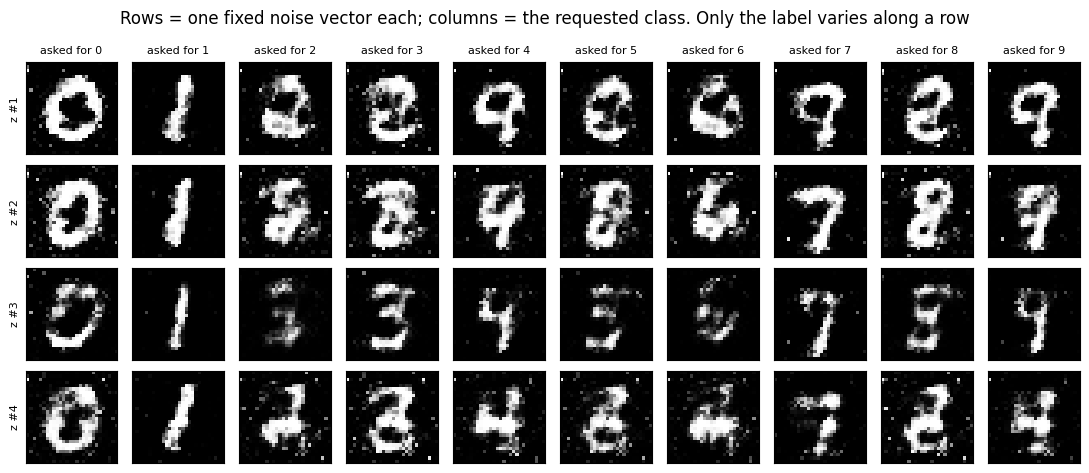

Mean pixel distance when only the LABEL changes (along a row):    14.88
Mean pixel distance when only the NOISE changes (down a column):  14.90

The two numbers come out close: in PIXEL terms, changing the label moves
the image about as much as changing the noise does. Pixel distance cannot
tell 'became a different digit' from 'same digit, different handwriting' —
which is exactly why you have to LOOK at the grid. Along a row the identity
changes; down a column the identity holds and only the style moves.


In [2]:
# WHAT/WHY: the 10-row figure above changes TWO things at once — the label and
# the noise. This cell isolates the label: each ROW holds one noise vector z
# fixed and walks the requested class 0..9 across the COLUMNS. Anything that
# changes along a row was caused by the label input and by nothing else.
n_rows = 4
G.eval()
with torch.no_grad():
    z_fixed = torch.randn(n_rows, LATENT_DIM)          # one z per row, reused across the row
    rows = []
    for r in range(n_rows):
        z_rep = z_fixed[r:r+1].repeat(N_CLASSES, 1)     # same z, ten times
        y_all = onehot(torch.arange(N_CLASSES))         # labels 0..9
        rows.append(G(torch.cat([z_rep, y_all], dim=1)).view(N_CLASSES, 28, 28))

fig, axes = plt.subplots(n_rows, N_CLASSES, figsize=(11, 1.2 * n_rows))
for r in range(n_rows):
    for c in range(N_CLASSES):
        axes[r, c].imshow(rows[r][c], cmap='gray', vmin=-1, vmax=1)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[0, c].set_title(f"asked for {c}", fontsize=8)
    axes[r, 0].set_ylabel(f"z #{r+1}", fontsize=8)
plt.suptitle("Rows = one fixed noise vector each; columns = the requested class. Only the label varies along a row")
plt.tight_layout(); plt.show()

# ── Measure both effects instead of eyeballing them ──────────────────────
stack = torch.stack(rows)                               # (rows, classes, 28, 28)
flat  = stack.reshape(n_rows, N_CLASSES, -1)
label_effect = torch.stack([torch.pdist(flat[r]).mean() for r in range(n_rows)]).mean()
noise_effect = torch.stack([torch.pdist(flat[:, c]).mean() for c in range(N_CLASSES)]).mean()
print(f"Mean pixel distance when only the LABEL changes (along a row):    {label_effect:.2f}")
print(f"Mean pixel distance when only the NOISE changes (down a column):  {noise_effect:.2f}")
print("\nThe two numbers come out close: in PIXEL terms, changing the label moves")
print("the image about as much as changing the noise does. Pixel distance cannot")
print("tell 'became a different digit' from 'same digit, different handwriting' —")
print("which is exactly why you have to LOOK at the grid. Along a row the identity")
print("changes; down a column the identity holds and only the style moves.")

**Read the grid along a row, not down a column.** Every image in a row was produced from the *same* 64-dimensional noise vector; the only thing that changed between neighbouring panels is which one-hot label was concatenated to it. The digit changes anyway. That is the controlled experiment the previous figure could not give you, because there the noise changed too — here the label is the only candidate explanation left.

Now read *down* a column: the requested digit stays the same while the handwriting changes — different slant, stroke weight and shape for each noise vector. That is the division of labour conditioning buys: **the label chooses what, the latent chooses how.**

The two printed distances are the honest surprise. They come out almost equal, so in pixel terms the label and the noise move the image by about the same amount. The metric cannot see the difference that matters — "this became a seven" versus "this seven is written differently" are the same size of change to it. That is the same limitation flagged for the pixel metrics in examples 07 and 09, and it is the reason this grid is evidence and the number beside it is not.

Note what the grid does *not* show. Row `z #1` produces several malformed panels, and ambiguous digits appear in every row: 15 CPU epochs on a fully-connected generator buys control, not quality. Do not read a correct-looking row as evidence of a good generator — that is what example 10's metrics and Unit 3's classifier check are for.

Judge accuracy on 3,000 REAL held-out digits: 95.4%
Read every number below against that ceiling, not against 100%.



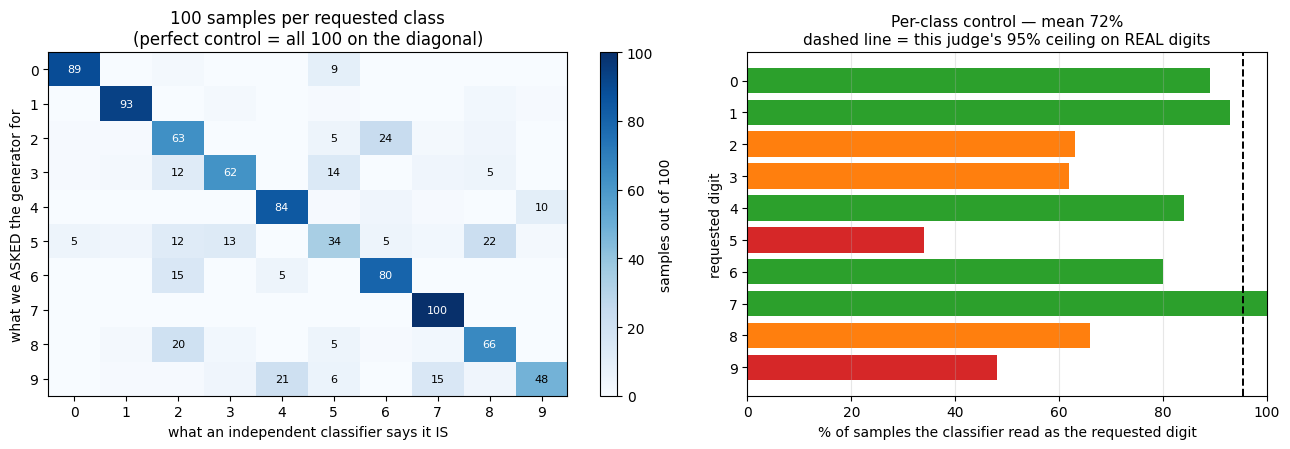

requested   read as requested   most common confusion
    0               89%            9 read as 5
    1               93%            3 read as 8
    2               63%            24 read as 6
    3               62%            14 read as 5
    4               84%            10 read as 9
    5               34%            22 read as 8
    6               80%            15 read as 2
    7              100%            0 read as 0
    8               66%            20 read as 2
    9               48%            21 read as 4

Mean over the ten classes: 71.9%  (judge's own ceiling: 95.4%)


In [3]:
# WHAT/WHY: "the label controls the output" is a claim, and so far the only
# evidence is our own eyes on two grids. This cell MEASURES it the way the
# "Where this breaks" note demands: train an independent classifier on REAL
# MNIST, ask the cGAN for 100 samples of each class, and check what the
# classifier thinks it was handed. The judge is trained on real data only and
# never sees the generator, so it cannot be in on the result.
import warnings
import numpy as np
from sklearn.neural_network import MLPClassifier

with warnings.catch_warnings():
    warnings.simplefilter("ignore")           # 40 iterations is a deliberate stop
    # ── Train the judge on 20,000 REAL training digits ────────────────────
    Xj = dataset.data[:20_000].numpy().reshape(20_000, -1) / 127.5 - 1.0
    yj = dataset.targets[:20_000].numpy()
    judge = MLPClassifier(hidden_layer_sizes=(128,), max_iter=40, random_state=0).fit(Xj, yj)

    # ── Baseline: how good is the judge on REAL held-out digits? ──────────
    test_set = torchvision.datasets.MNIST('./data/mnist', train=False, download=True)
    Xt = test_set.data[:3000].numpy().reshape(3000, -1) / 127.5 - 1.0
    yt = test_set.targets[:3000].numpy()
judge_acc = judge.score(Xt, yt)
print(f"Judge accuracy on 3,000 REAL held-out digits: {judge_acc:.1%}")
print("Read every number below against that ceiling, not against 100%.\n")

# ── Ask the generator for 100 of each class and let the judge read them ───
N_PER = 100
conf = np.zeros((N_CLASSES, N_CLASSES))       # rows = requested, cols = judged
G.eval()
with torch.no_grad():
    for cls in range(N_CLASSES):
        z = torch.randn(N_PER, LATENT_DIM)
        y = onehot(torch.full((N_PER,), cls))
        imgs = G(torch.cat([z, y], dim=1)).numpy()      # already in [-1, 1]
        for v in judge.predict(imgs):
            conf[cls, int(v)] += 1
match_rate = np.diag(conf) / N_PER
overall = match_rate.mean()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6),
                               gridspec_kw=dict(width_ratios=[1.25, 1]))
# aspect="auto" lets the matrix fill its panel — a square matrix would leave a
# wide empty band under both panels.
im = axL.imshow(conf, cmap="Blues", vmin=0, vmax=N_PER, aspect="auto")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if conf[i, j] >= 5:                    # only label cells worth reading
            axL.text(j, i, int(conf[i, j]), ha="center", va="center", fontsize=8,
                     color="white" if conf[i, j] > N_PER * 0.55 else "black")
axL.set_xticks(range(N_CLASSES)); axL.set_yticks(range(N_CLASSES))
axL.set_xlabel("what an independent classifier says it IS")
axL.set_ylabel("what we ASKED the generator for")
axL.set_title(f"100 samples per requested class\n(perfect control = all 100 on the diagonal)")
fig.colorbar(im, ax=axL, label="samples out of 100")

axR.barh(range(N_CLASSES), match_rate * 100,
         color=["tab:green" if m >= 0.8 else "tab:orange" if m >= 0.5 else "tab:red"
                for m in match_rate])
axR.axvline(judge_acc * 100, color="black", ls="--", lw=1.4)
# The ceiling is named in the title, not as a rotated label: a vertical label
# here would lie across the bars it is supposed to be compared with.
axR.set_yticks(range(N_CLASSES)); axR.invert_yaxis()
axR.set_xlim(0, 100); axR.set_xlabel("% of samples the classifier read as the requested digit")
axR.set_ylabel("requested digit")
axR.set_title(f"Per-class control — mean {overall:.0%}\n"
              f"dashed line = this judge's {judge_acc:.0%} ceiling on REAL digits", fontsize=11)
axR.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print("requested   read as requested   most common confusion")
for cls in range(N_CLASSES):
    off = conf[cls].copy(); off[cls] = -1
    worst = int(off.argmax())
    print(f"    {cls}            {match_rate[cls]*100:5.0f}%            "
          f"{int(off[worst])} read as {worst}")
print(f"\nMean over the ten classes: {overall:.1%}  (judge's own ceiling: {judge_acc:.1%})")

**Read the measurement, not the vibe.** The two grids above are evidence you assessed by eye. This is the same claim handed to a classifier that was trained only on real MNIST and has never seen the generator.

*The heatmap.* Rows are what we asked for, columns are what the judge says it got. Perfect label control would put all 100 samples of every row on the diagonal. Read across a row to see where a class leaks: a bright off-diagonal cell is a class the generator does not reliably produce, and the printed table names each one.

*The bars.* Per-class control, with the black dashed line marking what this judge scores on **real** held-out digits. That line is the practical resolution limit: the judge misreads about one real digit in twenty, so any bar up in the nineties is already as good as this measurement can tell. Green bars are classes under control; orange and red are classes where "the label controls the output" is simply not true yet at 15 CPU epochs.

One bar goes *past* the line: the requested 7s are read as 7s 100% of the time, better than the judge manages on real human 7s. That is not the generator being superhuman — it is the generator being **stereotyped**. Look back at the "asked for 7" row of the first figure: those 7s resemble each other far more than eight real 7s would. A class that is easier to classify than reality is a class whose variety has collapsed, and it is worth as much suspicion as a low bar.

The spread across classes is the finding. Conditioning is not a switch that is either on or off: it works well for the classes with distinctive, well-separated shapes and degrades on the ones the generator renders as ambiguous scribbles. That is the concrete version of the warning below — conditioning gives you *a mechanism* for control, and you only find out how much control you actually got by measuring it.

## 💬 Discuss

1. D judges image–label *pairs*, not images. Predict precisely what would go wrong if you conditioned G but left D unconditional — then say how you would spot that failure in the 10-row figure above.
2. Our samples are rough after 15 CPU epochs, and the measured per-class control below is uneven — some rows are unmistakably the requested digit, others are not. For a customer-facing design tool, which matters more? Does your answer change for a medical data-augmentation tool like the one in example 05?
3. One-hot conditioning gives ten choices. What breaks when a client needs ten thousand — "a shirt in *this* fabric", from a photograph? Name the change you would have to make to G's input.


## ⚠️ Where this breaks

**Conditioning guarantees nothing on its own.** G honours the label only because D can punish mismatched image–label pairs. Where a class is rare in the training data, D has seen few real pairs for it, so the punishment is weak and the guarantee degrades — precisely for the classes you most wanted control over.

**One-hot conditioning does not scale.** Past a few dozen discrete classes you need an embedding — text, pose, depth, a reference image — which is what ControlNet and every text-to-image system do. The concatenation trick is the idea; the one-hot vector is not.

**The label controls *which*, never *how good*.** Our rows show the correct digits and they are still blurry. No amount of conditioning improves sample quality; that is the job of architecture, data and training budget (examples 07–09).

**Verify, do not assume.** "The label is in the input" is not evidence the label is being honoured. Example 03 of Unit 3 measures it: a separate classifier checks what fraction of generated samples actually match the requested class. Build that check into any conditional generator you ship.


---

## 🔭 State of the field (2026)

*Enrichment, not examinable content — the official unit examines the technique above exactly as it is taught. This box says where that technique sits on the 2026 map.*

Discuss question 3 asks what breaks when a client needs ten thousand conditions instead of ten, and 2026 has
three answers, none of which is a longer one-hot vector. Text conditioning became *architecture*: current
rectified-flow transformers give image and text tokens separate weights and let the two streams attend to each
other, rather than concatenating a label onto an input (Esser *et al.* 2024). Spatial conditions — pose, depth,
edge maps — arrive through a side network instead (ControlNet, Zhang *et al.* 2023, listed below). And the
condition itself is now typically a natural-language *instruction*, read by a vision-language model that steers
the generator: VIBE pairs a 2B-parameter Qwen3-VL with a 1.6B-parameter Sana1.5 diffusion model, fits the whole
pipeline into 24 GB of GPU memory, and edits at up to 2K resolution in roughly four seconds on an H100
(Alekseenko *et al.* 2026).

**Why this lesson is still exactly the right thing to learn.** Every one of those systems keeps the mechanism
you implemented: the condition has to reach the *judge* as well as the generator, or nothing punishes an output
that ignores it. The controlled experiment you ran — change one thing, attribute one new behaviour — is how you
establish that a control signal is doing anything at all, and the classifier check afterwards is exactly how
instruction-following is scored today: a separate model counts how often the output matches what was asked for,
class by class, instead of by eye. Your uneven per-class bars are the honest picture of what conditioning buys,
and the official plan examines this conditional GAN.

**Read:** Esser *et al.* (2024), <https://arxiv.org/abs/2403.03206> · Alekseenko *et al.* (2026),
<https://arxiv.org/abs/2601.02242> (both listed below).

---

## 📚 References & Further Reading

**Papers:**
- Mirza & Osindero (2014) — [Conditional Generative Adversarial Nets](https://arxiv.org/abs/1411.1784) *(the cGAN idea used above)*
- Isola et al. (2017) — [Pix2Pix: Image-to-Image Translation](https://arxiv.org/abs/1611.07004) *(conditioning on entire images)*
- Zhu et al. (2017) — [CycleGAN](https://arxiv.org/abs/1703.10593) *(translation without paired data)*
- Zhang et al. (2023) — [Adding Conditional Control to Text-to-Image Diffusion Models (ControlNet)](https://arxiv.org/abs/2302.05543) *(today's standard way to condition image generators)*

**Applications:** medical image synthesis by pathology label, satellite-to-map conversion, sketch-to-photo tools

**Recent (2024–2026) — the same conditioning contract, current systems:**
- Esser et al. (2024) — [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206) *(text conditioning done with separate weights per modality and bidirectional flow between image and text tokens — conditioning as an architecture, not a concatenated one-hot)*
- Meituan LongCat Team (2025) — [LongCat-Video Technical Report](https://arxiv.org/abs/2510.22200) *(one 13.6B model covering text-to-video, image-to-video and video continuation — three products from one conditional-generation contract)*
- Alekseenko et al. (2026) — [VIBE: Visual Instruction Based Editor](https://arxiv.org/abs/2601.02242) *(conditioning as a natural-language instruction: a 2B-parameter Qwen3-VL reads the edit request and steers a 1.6B-parameter Sana1.5 diffusion model; the pipeline fits in 24 GB and edits at up to 2K resolution in roughly four seconds on an H100)*


## 📝 Summary

You built a **conditional GAN** by making exactly three changes to example 05's unconditional GAN: label concatenated into G's input, into D's input, and into every training step. The result (see the 10-row figure) is **class-controlled generation** — and the classifier check measures how much control that actually bought, class by class, instead of asserting it. Conditioning on richer signals (full images in Pix2Pix, text embeddings in text-to-image systems) follows the same principle.
